# EduTrack Data Exploration & Cleaning

## Overview
This notebook covers:
- Data loading and initial exploration
- Data quality assessment
- Missing value analysis
- Data cleaning and normalization
- Before/after comparison

In [ ]:
import sys
import os

# Add project root to path (notebooks are in /notebooks subdirectory)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization defaults
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


## 1. Data Loading

In [ ]:
import sys
import os

# Import data processing modules
from src.data_processing.loader import DataLoader
from src.data_processing.cleaner import DataCleaner

# Load raw data
data_dir = os.path.join(project_root, 'data/raw')
loader = DataLoader(data_dir=data_dir)
df_raw = loader.load_college_data()

print(f"Dataset Shape: {df_raw.shape}")
print(f"\nColumns ({len(df_raw.columns)}):")
print(df_raw.columns.tolist())

Dataset Shape: (5446, 20)

Columns (20):
['College Name', 'Genders Accepted', 'Campus Size', 'Total_Students', 'Total_Faculty', 'Established Year', 'Rating', 'University', 'Courses', 'Facilities', 'City', 'State', 'Country', 'College Type', 'Average Fees', 'Infrastructure_Area', 'Placement_Rate', 'Fund_Utilization', 'Avg_Doc_DSS', 'Missing_Doc_Count']


## 2. Data Quality Assessment

In [15]:
# Check for data issues
is_valid, issues = loader.validate_data(df_raw)

print("Data Validation Results:")
print(f"Valid: {is_valid}\n")

if issues:
    print("Issues Found:")
    for i, issue in enumerate(issues, 1):
        print(f"  {i}. {issue}")
else:
    print("No major issues found!")

Data Validation Results:
Valid: False

Issues Found:
  1. Column 'Genders Accepted' has 18 missing values (0.3%)
  2. Column 'Campus Size' has 2751 missing values (50.5%)
  3. Column 'Established Year' has 101 missing values (1.9%)
  4. Column 'Rating' has 5113 missing values (93.9%)
  5. Column 'University' has 1936 missing values (35.5%)
  6. Column 'Facilities' has 12 missing values (0.2%)
  7. Column 'College Type' has 1 missing values (0.0%)


## 3. Missing Values Analysis

Missing Values Summary:
          Column  Missing_Count  Missing_Pct
          Rating           5113        93.89
     Campus Size           2751        50.51
      University           1936        35.55
Established Year            101         1.85
Genders Accepted             18         0.33
      Facilities             12         0.22
    College Type              1         0.02


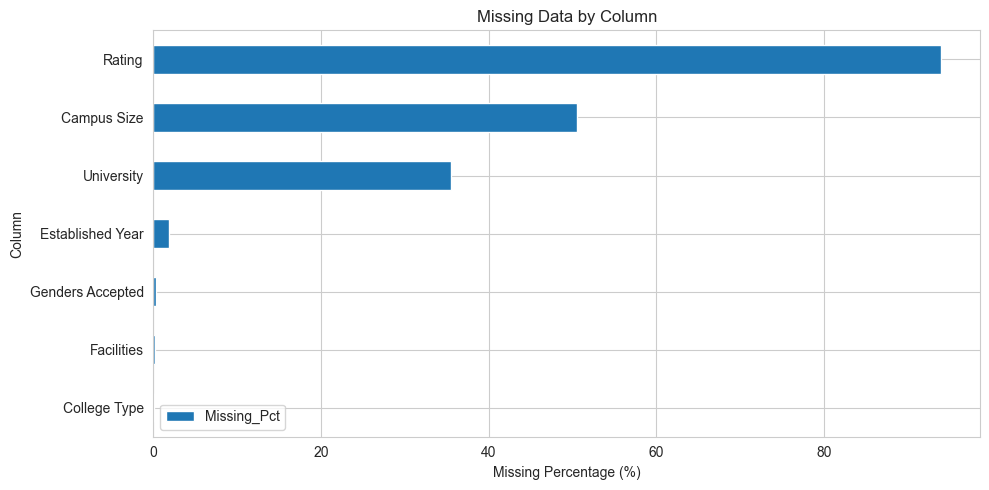

In [16]:
# Calculate missing values
missing_data = pd.DataFrame({
    'Column': df_raw.columns,
    'Missing_Count': df_raw.isnull().sum(),
    'Missing_Pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
}).sort_values('Missing_Pct', ascending=False)

missing_data = missing_data[missing_data['Missing_Count'] > 0]

print("Missing Values Summary:")
print(missing_data.to_string(index=False))

# Visualize missing values
if len(missing_data) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    missing_data.sort_values('Missing_Pct').plot(x='Column', y='Missing_Pct', kind='barh', ax=ax)
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_title('Missing Data by Column')
    plt.tight_layout()
    plt.show()

## 4. Data Type Analysis

In [17]:
# Analyze data types
dtype_info = pd.DataFrame({
    'Column': df_raw.columns,
    'Data_Type': df_raw.dtypes,
    'Non_Null_Count': df_raw.count(),
    'Unique_Values': df_raw.nunique()
})

print("Data Type Summary:")
print(dtype_info.to_string(index=False))

Data Type Summary:
             Column Data_Type  Non_Null_Count  Unique_Values
       College Name    object            5446           4831
   Genders Accepted    object            5428              5
        Campus Size    object            2695            255
     Total_Students   float64            5446           2207
      Total_Faculty   float64            5446            419
   Established Year    object            5345            111
             Rating    object             333            110
         University    object            3510            198
            Courses    object            5446           4767
         Facilities    object            5434           1812
               City    object            5446           2389
              State    object            5446             35
            Country    object            5446              2
       College Type    object            5445              3
       Average Fees    object            5446           3269
Infra

## 5. Numeric Columns Analysis

In [18]:
# Numeric statistics
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns

print(f"Numeric Columns ({len(numeric_cols)}):")
print(df_raw[numeric_cols].describe().round(2))

Numeric Columns (7):
       Total_Students  Total_Faculty  Infrastructure_Area  Placement_Rate  \
count         5446.00        5446.00              5446.00         5446.00   
mean          1711.01          95.89                44.95           60.60   
std          16630.20         112.21               238.32           12.21   
min              1.00           1.00                 0.00           40.03   
25%            492.00          38.00                23.00           50.39   
50%            812.00          69.00                23.00           60.43   
75%           1295.75         122.00                23.00           70.50   
max        1035081.00        2453.00             16000.00           98.89   

       Fund_Utilization  Avg_Doc_DSS  Missing_Doc_Count  
count           5446.00      5446.00            5446.00  
mean              67.92        62.84               0.39  
std               10.56        13.47               0.66  
min               50.00        40.03               0.

## 6. Data Cleaning

In [19]:
# Clean data
cleaner = DataCleaner()
df_cleaned = cleaner.clean_dataframe(df_raw)

print("Cleaning Complete!")
print(f"Original Shape: {df_raw.shape}")
print(f"Cleaned Shape: {df_cleaned.shape}")

Could not convert 'Established Year' to Int64: invalid literal for int() with base 10: 'Unknown'
Could not convert 'Average Fees' to float64: could not convert string to float: 'Average Fees'
Could not convert 'Rating' to float64: could not convert string to float: 'Unknown'


Cleaning Complete!
Original Shape: (5446, 20)
Cleaned Shape: (4831, 20)


## 7. Before/After Comparison

In [20]:
# Compare raw vs cleaned
comparison = pd.DataFrame({
    'Metric': ['Total Rows', 'Total Columns', 'Missing Values', 'Duplicates', 'Memory Usage (MB)'],
    'Raw': [
        len(df_raw),
        len(df_raw.columns),
        df_raw.isnull().sum().sum(),
        df_raw.duplicated().sum(),
        round(df_raw.memory_usage(deep=True).sum() / 1024**2, 2)
    ],
    'Cleaned': [
        len(df_cleaned),
        len(df_cleaned.columns),
        df_cleaned.isnull().sum().sum(),
        df_cleaned.duplicated().sum(),
        round(df_cleaned.memory_usage(deep=True).sum() / 1024**2, 2)
    ]
})

print("\nBefore/After Comparison:")
print(comparison.to_string(index=False))


Before/After Comparison:
           Metric     Raw  Cleaned
       Total Rows 5446.00  4831.00
    Total Columns   20.00    20.00
   Missing Values 9932.00     0.00
       Duplicates    0.00     0.00
Memory Usage (MB)    7.42     6.41


## 8. Save Cleaned Data

In [ ]:
import sys
import os

# Save cleaned data
output_path = os.path.join(project_root, 'data/processed/college_data_cleaned.csv')
os.makedirs(os.path.dirname(output_path), exist_ok=True)

df_cleaned.to_csv(output_path, index=False)
print(f"✓ Saved cleaned data to: {output_path}")

# Summary
print(f"\nCleaning Summary:")
print(f"- Rows preserved: {len(df_cleaned)} ({(len(df_cleaned)/len(df_raw)*100):.1f}%)")
print(f"- Missing values: {df_raw.isnull().sum().sum()} → {df_cleaned.isnull().sum().sum()}")
print(f"- Data quality: {'GOOD' if df_cleaned.isnull().sum().sum() == 0 else 'ACCEPTABLE'}")

OSError: Cannot save file into a non-existent directory: 'data\processed'